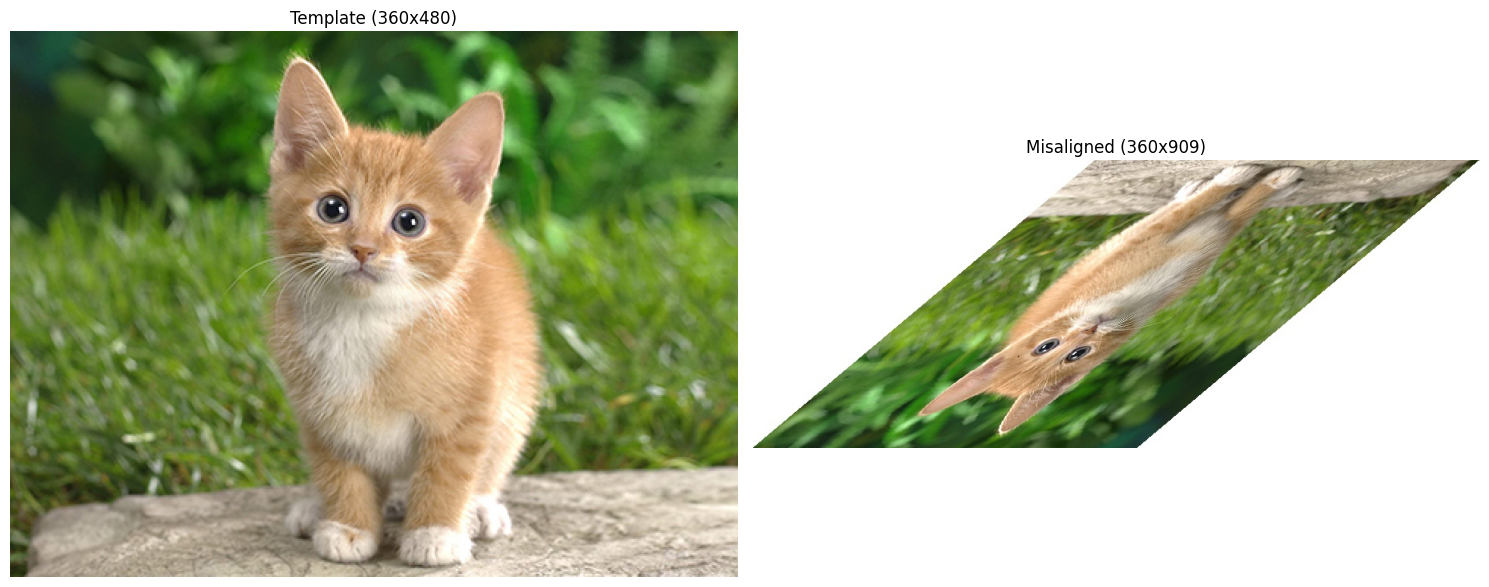

Template keypoints: 867
Misaligned keypoints: 869

Using ratio 0.85: 54 matches


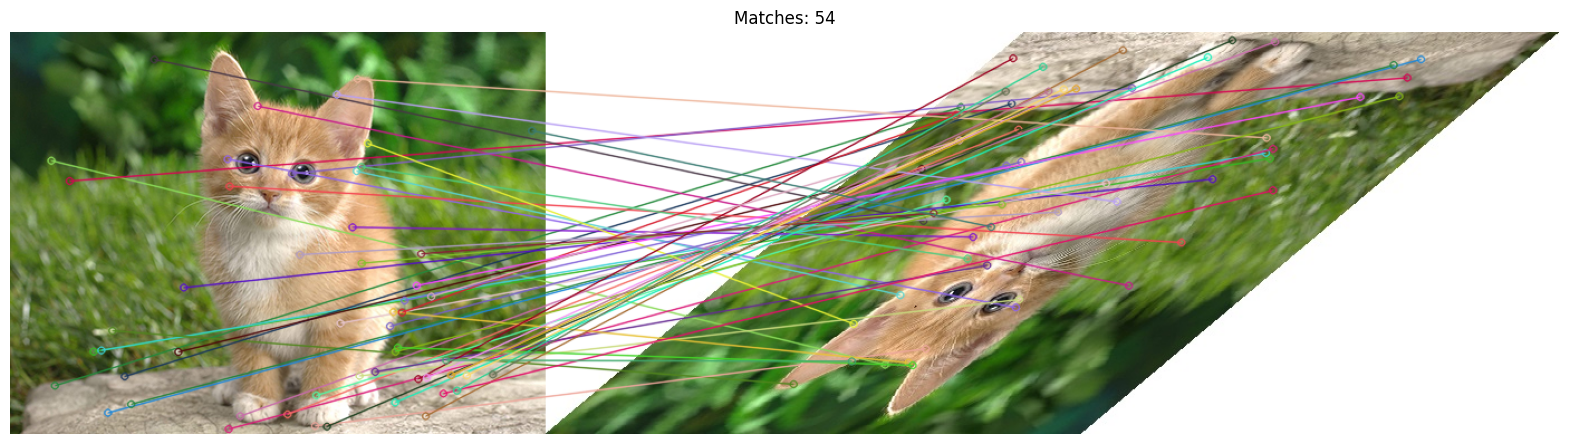

RANSAC inliers: 16 out of 54


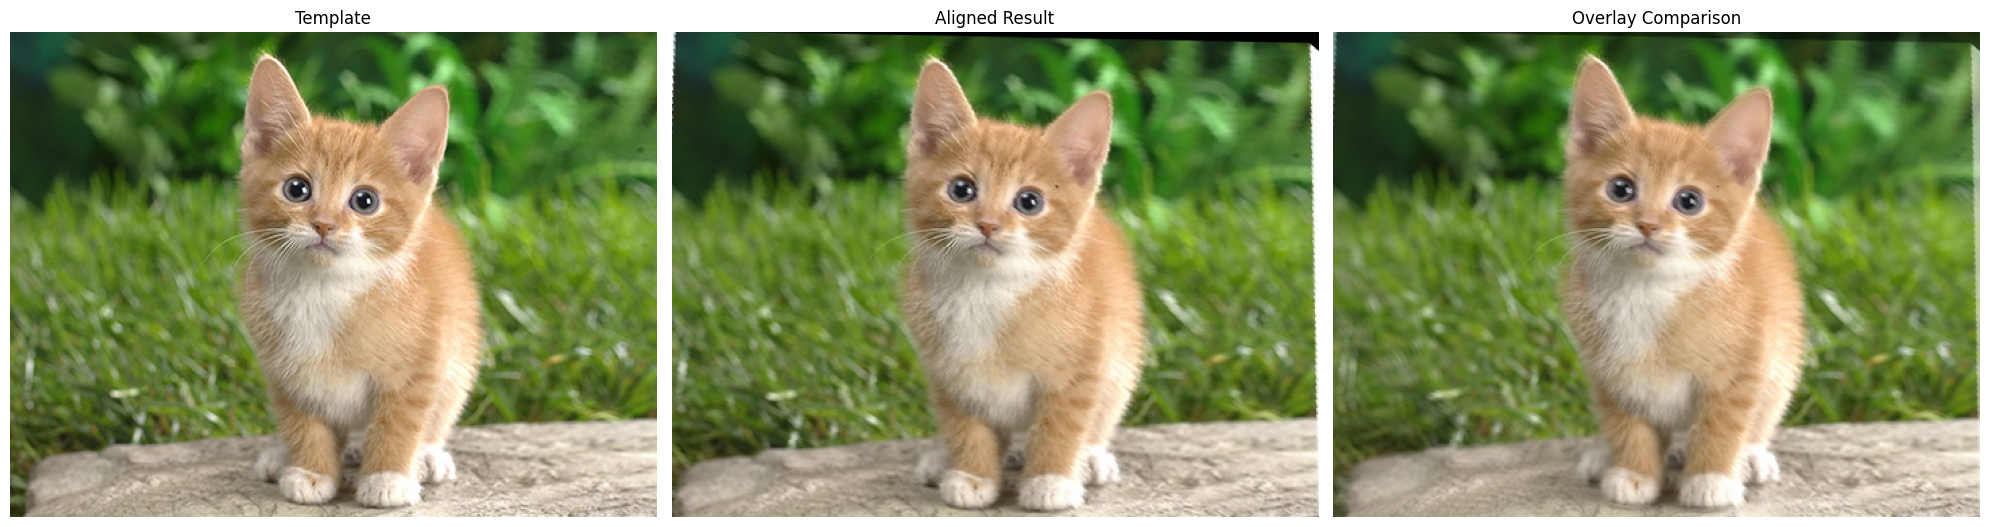

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

template_image = cv2.imread("images/cat.jpg")
misaligned_image = cv2.imread("images/cat_a.jpg")

# Visualize both images side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].imshow(cv2.cvtColor(template_image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Template (360x480)")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(misaligned_image, cv2.COLOR_BGR2RGB))
axes[1].set_title("Misaligned (360x909)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

# Try different feature detectors and less strict matching
grey_template = cv2.cvtColor(template_image, cv2.COLOR_BGR2GRAY)
grey_misaligned = cv2.cvtColor(misaligned_image, cv2.COLOR_BGR2GRAY)

detector = cv2.SIFT_create(nfeatures=2000)
kp1, desc1 = detector.detectAndCompute(grey_template, None)
kp2, desc2 = detector.detectAndCompute(grey_misaligned, None)

print(f"Template keypoints: {len(kp1)}")
print(f"Misaligned keypoints: {len(kp2)}")

# Use appropriate matcher based on descriptor type
matcher = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
knn_matches = matcher.knnMatch(desc1, desc2, k=2)


def get_threshold(knn_matches):
    good_matches_length = 0
    good_matches = []
    for ratio_threshold in [0.85, 0.8, 0.75, 0.7, 0.65]:
        matches = []
        for match_pair in knn_matches:
            if len(match_pair) == 2:
                m, n = match_pair  # m is the best match, n is the second best match
                if m.distance < ratio_threshold * n.distance:
                    matches.append(m)
        if len(matches) > good_matches_length:
            good_matches_length = len(matches)
            threshold = ratio_threshold
            good_matches = matches

    return threshold or 0.7, good_matches


ratio_threshold, good_matches = get_threshold(knn_matches)
print(f"\nUsing ratio {ratio_threshold}: {len(good_matches)} matches")

if len(good_matches) >= 4:  # Minimum for homography
    # Show matches
    img_matches = cv2.drawMatches(
        template_image,
        kp1,
        misaligned_image,
        kp2,
        good_matches,
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
    )

    plt.figure(figsize=(20, 10))
    plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
    plt.title(f"Matches: {len(good_matches)}")
    plt.axis("off")
    plt.show()

    # Extract points
    points1 = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    points2 = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

    h, mask = cv2.findHomography(
        points2,
        points1,
        cv2.RANSAC,
        ransacReprojThreshold=10.0,
        maxIters=10000,
        confidence=0.95,
    )

    if h is not None and mask is not None:
        inliers = np.sum(mask)  # points that matches the homography
        print(f"RANSAC inliers: {inliers} out of {len(good_matches)}")

        if inliers >= 4:
            # Apply transformation
            height, width = template_image.shape[:2]
            aligned_image = cv2.warpPerspective(misaligned_image, h, (width, height))

            # Show results
            fig, axes = plt.subplots(1, 3, figsize=(20, 7))

            axes[0].imshow(cv2.cvtColor(template_image, cv2.COLOR_BGR2RGB))
            axes[0].set_title("Template")
            axes[0].axis("off")

            axes[1].imshow(cv2.cvtColor(aligned_image, cv2.COLOR_BGR2RGB))
            axes[1].set_title("Aligned Result")
            axes[1].axis("off")

            # Overlay
            overlay = cv2.addWeighted(template_image, 0.5, aligned_image, 0.5, 0)
            axes[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
            axes[2].set_title("Overlay Comparison")
            axes[2].axis("off")

            plt.tight_layout()
            plt.show()
        else:
            print("Not enough inliers for reliable homography")
    else:
        print("Could not compute homography")
else:
    print("Not enough matches - the images might not have sufficient overlap")

469


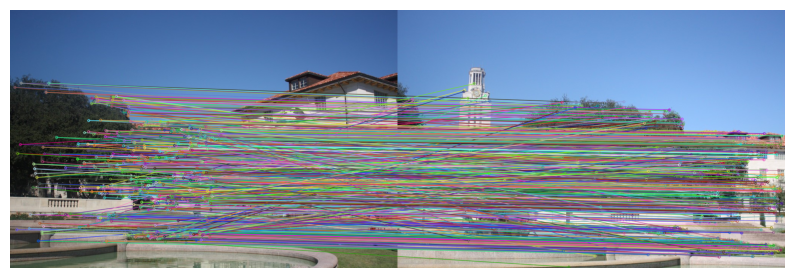

[[ 7.63138494e-01  3.82477503e-02  4.46715821e+02]
 [-1.36569965e-01  9.12083236e-01  7.62578699e+01]
 [-2.13482598e-04 -3.12847564e-05  1.00000000e+00]]


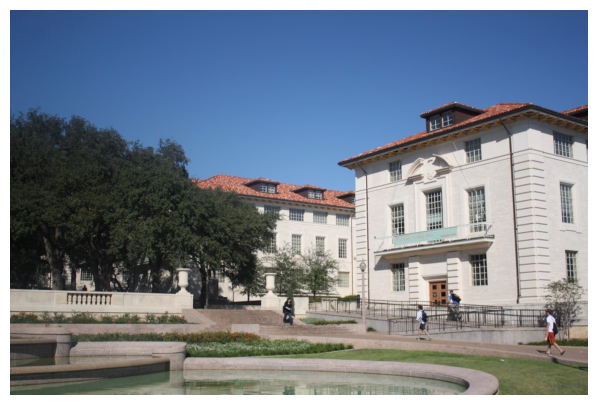

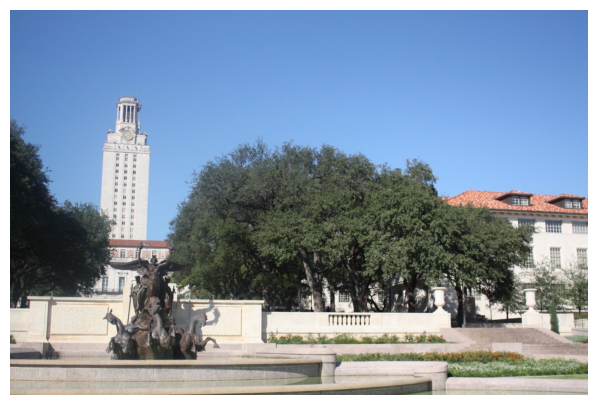

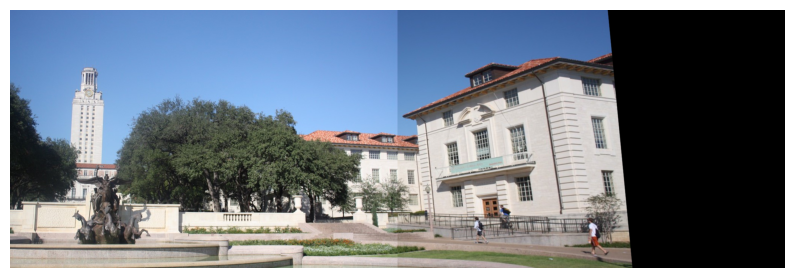

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


img1 = cv2.imread("images/foto1A.jpg")
img2 = cv2.imread("images/foto1B.jpg")
img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(img1_gray, None)
kp2, des2 = sift.detectAndCompute(img2_gray, None)

bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)
good = []
ratio = 0.4
for m in matches:
    if m[0].distance < ratio * m[1].distance:
        good.append(m)

# good = sorted(good, key=lambda x: x.distance, reverse=True)
# good = good[:200]

print(len(good))

img3 = cv2.drawMatchesKnn(
    img1, kp1, img2, kp2, good, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

kp1 = np.float32([kp.pt for kp in kp1])
kp2 = np.float32([kp.pt for kp in kp2])
pts1 = np.float32([kp1[m[0].queryIdx] for m in matches])
pts2 = np.float32([kp2[m[0].trainIdx] for m in matches])

# estimate the homography between the sets of points
(H, status) = cv2.findHomography(pts1, pts2, cv2.RANSAC)
print(H)

h1, w1 = img1.shape[:2]
h2, w2 = img2.shape[:2]
result = cv2.warpPerspective(img1, H, (w1 + w2, h1))
result[0:h2, 0:w2] = img2

plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()